# Linear Regression Analysis: Housing Price Prediction
This notebook demonstrates the implementation of a Linear Regression model using `scikit-learn` to predict housing prices using the `Housing.csv` dataset. The dataset includes housing details such as house size (area), number of bedrooms, number of bathrooms, number of stories, main road access, presence of guestrooms/basements/hot water/air conditioning, parking spaces, preference area, and furnishing status.

---

## 1. Imports and Setup
First, we import the necessary libraries for data manipulation, analysis, visualization, and modeling.

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# Set styling for charts
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'figure.titlesize': 14,
    'figure.dpi': 150,
    'savefig.dpi': 150
})
print("Libraries successfully imported.")

Libraries successfully imported.


## 2. Load the Dataset
We load the housing price dataset and inspect its structure.

In [2]:
dataset_path = os.path.join('..', 'dataset', 'Housing.csv')
df = pd.read_csv(dataset_path)
df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


## 3. Data Preprocessing
To prepare the dataset for Linear Regression, we need to handle categorical variables:
- **Binary variables** (`mainroad`, `guestroom`, `basement`, `hotwaterheating`, `airconditioning`, `prefarea`): Map 'yes' to 1 and 'no' to 0.
- **Multi-class categorical variable** (`furnishingstatus`): Encode using dummy variables (one-hot encoding) and drop the first category (`furnished`) as reference.

In [3]:
df_processed = df.copy()

# Map binary variables
binary_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
for col in binary_cols:
    if col in df_processed.columns:
        df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

# One-hot encode furnishingstatus
if 'furnishingstatus' in df_processed.columns:
    df_processed = pd.get_dummies(df_processed, columns=['furnishingstatus'], drop_first=True, dtype=int)

# Rename columns to standard Title Case format
rename_dict = {
    'price': 'Price',
    'area': 'Area',
    'bedrooms': 'Bedrooms',
    'bathrooms': 'Bathrooms',
    'stories': 'Stories',
    'mainroad': 'Main_Road_Access',
    'guestroom': 'Has_Guestroom',
    'basement': 'Has_Basement',
    'hotwaterheating': 'Has_Hot_Water',
    'airconditioning': 'Has_Air_Conditioning',
    'parking': 'Parking_Spaces',
    'prefarea': 'Preferred_Area',
    'furnishingstatus_semi-furnished': 'Furnished_Semi',
    'furnishingstatus_unfurnished': 'Furnished_No'
}
df_processed = df_processed.rename(columns=rename_dict)
df_processed.head(10)

,Price,Area,Bedrooms,Bathrooms,Stories,Main_Road_Access,Has_Guestroom,Has_Basement,Has_Hot_Water,Has_Air_Conditioning,Parking_Spaces,Preferred_Area,Furnished_Semi,Furnished_No
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0
5,10850000,7500,3,3,1,1,0,1,0,1,2,1,1,0
6,10150000,8580,4,3,4,1,0,0,0,1,2,1,1,0
7,10150000,16200,5,3,2,1,0,0,0,0,0,0,0,1
8,9870000,8100,4,1,2,1,1,1,0,1,2,1,0,0
9,9800000,5750,3,2,4,1,1,0,0,1,1,1,0,1


## 4. Exploratory Data Analysis (EDA)
Now we analyze the preprocessed dataset using descriptive statistics and correlation heatmaps.

In [4]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Price                 545 non-null    int64
 1   Area                  545 non-null    int64
 2   Bedrooms              545 non-null    int64
 3   Bathrooms             545 non-null    int64
 4   Stories               545 non-null    int64
 5   Main_Road_Access      545 non-null    int64
 6   Has_Guestroom         545 non-null    int64
 7   Has_Basement          545 non-null    int64
 8   Has_Hot_Water         545 non-null    int64
 9   Has_Air_Conditioning  545 non-null    int64
 10  Parking_Spaces        545 non-null    int64
 11  Preferred_Area        545 non-null    int64
 12  Furnished_Semi        545 non-null    int32
 13  Furnished_No          545 non-null    int32
dtypes: int32(2), int64(12)
memory usage: 55.5 KB


In [5]:
df_processed.describe()

,Price,Area,Bedrooms,Bathrooms,Stories,Main_Road_Access,Has_Guestroom,Has_Basement,Has_Hot_Water,Has_Air_Conditioning,Parking_Spaces,Preferred_Area,Furnished_Semi,Furnished_No
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.858716,0.177982,0.350459,0.045872,0.315596,0.693578,0.234862,0.416514,0.326606
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.348635,0.382849,0.477552,0.209399,0.465180,0.861586,0.424302,0.493434,0.469402
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,1.000000,1.000000


### 4.1 Feature Correlation Heatmap
We plot a correlation matrix heatmap to check relationships between all numeric variables.

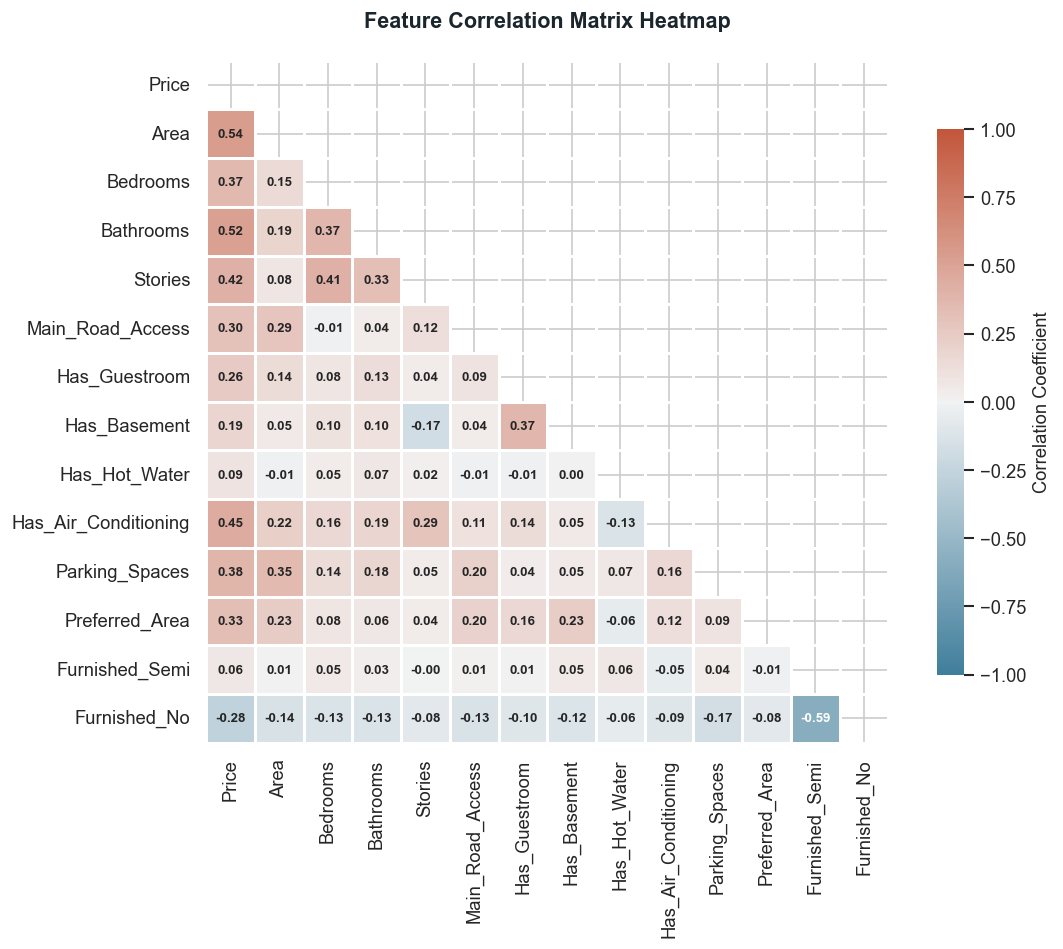

In [6]:
plt.figure(figsize=(10, 8))
corr = df_processed.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(
    corr, 
    mask=mask, 
    cmap=cmap, 
    vmax=1.0, 
    vmin=-1.0, 
    center=0,
    square=True, 
    linewidths=.8, 
    cbar_kws={"shrink": .8, "label": "Correlation Coefficient"},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8, "weight": "bold"}
)
plt.title("Feature Correlation Matrix Heatmap", pad=20, weight='bold', color='#1A252C')
plt.tight_layout()
plt.show()

### 4.2 House Price vs. Area
Let's see the linear regression trend line of Price vs Area (sq ft).

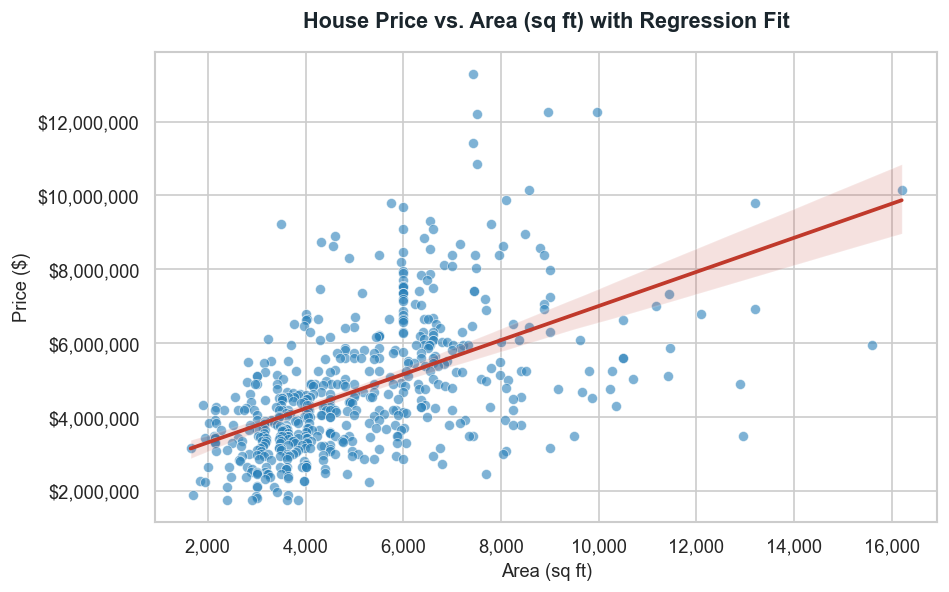

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_processed, x='Area', y='Price', alpha=0.6, color='#2980B9', edgecolor='w')
sns.regplot(data=df_processed, x='Area', y='Price', scatter=False, color='#C0392B')
plt.title("House Price vs. Area (sq ft) with Regression Fit", weight='bold', color='#1A252C', pad=15)
plt.xlabel("Area (sq ft)")
plt.ylabel("Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x:,.0f}"))
plt.tight_layout()
plt.show()

## 5. Feature Engineering and Preprocessing
We separate our target variable `Price` from the feature matrix `X`. Then, we perform a train-test split (80% training, 20% testing). Finally, we scale the features using `StandardScaler` to bring all features to a common scale for modeling.

In [8]:
X = df_processed.drop(columns=['Price'])
y = df_processed['Price']
feature_names = X.columns.tolist()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training set shape: (436, 13)
Testing set shape: (109, 13)


## 6. Model Training
We instantiate and train a standard Linear Regression model from `scikit-learn`.

In [9]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Model training complete.")

Model training complete.


## 7. Model Evaluation
We evaluate the model on the testing set using several metrics:
- **R² Score (Coefficient of Determination)**
- **Mean Absolute Error (MAE)**
- **Mean Squared Error (MSE)**
- **Root Mean Squared Error (RMSE)**

In [10]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

# Metrics
mae = metrics.mean_absolute_error(y_test, y_pred_test)
mse = metrics.mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred_test)

mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
r2_train = metrics.r2_score(y_train, y_pred_train)

print("Evaluation Summary:")
print("-------------------")
print(f"Train R² Score:         {r2_train:.4f}")
print(f"Train MAE:              ${mae_train:,.2f}")
print("-------------------")
print(f"Test R² Score (R-sq):   {r2:.4f}")
print(f"Test MAE:               ${mae:,.2f}")
print(f"Test MSE:               {mse:,.2f}")
print(f"Test RMSE:              ${rmse:,.2f}")

Evaluation Summary:
-------------------
Train R² Score:         0.6859
Train MAE:              $719,242.89
-------------------
Test R² Score (R-sq):   0.6529
Test MAE:               $970,043.40
Test MSE:               1,754,318,687,330.67
Test RMSE:              $1,324,506.96


### 7.1 Actual vs. Predicted Prices Plot
Let's see how close the predictions are to the actual values on the test set.

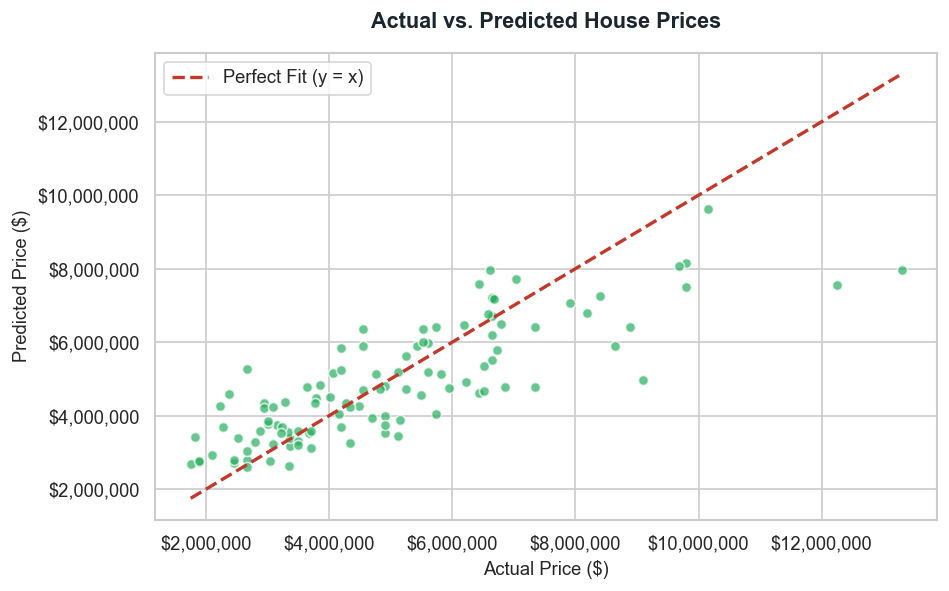

In [11]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_test, alpha=0.7, color='#27AE60', edgecolor='w')

max_val = max(y_test.max(), y_pred_test.max())
min_val = min(y_test.min(), y_pred_test.min())
plt.plot([min_val, max_val], [min_val, max_val], color='#C0392B', linestyle='--', linewidth=2, label='Perfect Fit (y = x)')

plt.title("Actual vs. Predicted House Prices", weight='bold', color='#1A252C', pad=15)
plt.xlabel("Actual Price ($)")
plt.ylabel("Predicted Price ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.legend()
plt.tight_layout()
plt.show()

### 7.2 Residual Plot
A residual plot is used to verify the linear regression assumptions (homoscedasticity and random error).

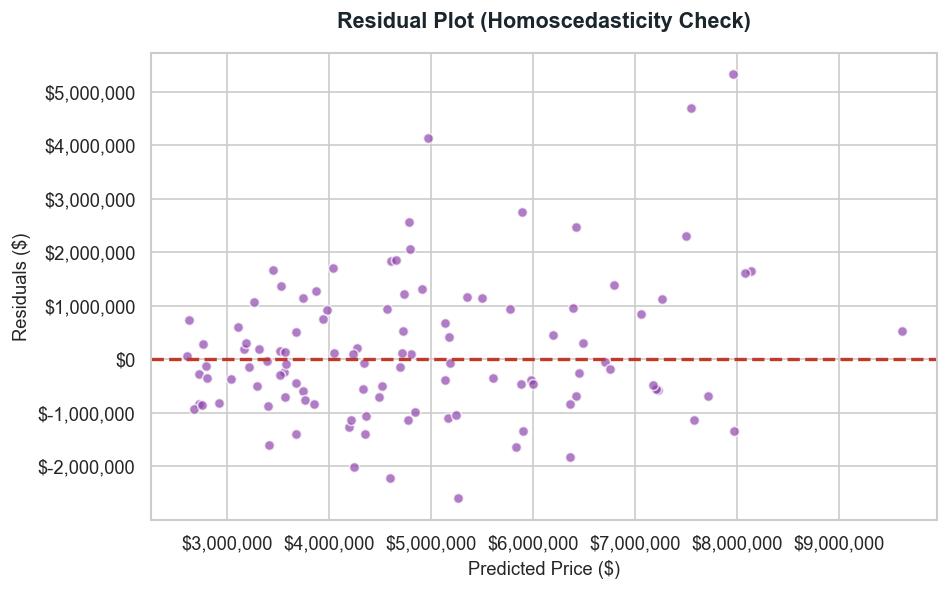

In [12]:
plt.figure(figsize=(8, 5))
residuals = y_test - y_pred_test
plt.scatter(y_pred_test, residuals, alpha=0.7, color='#8E44AD', edgecolor='w')
plt.axhline(y=0, color='#C0392B', linestyle='--', linewidth=2)

plt.title("Residual Plot (Homoscedasticity Check)", weight='bold', color='#1A252C', pad=15)
plt.xlabel("Predicted Price ($)")
plt.ylabel("Residuals ($)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.tight_layout()
plt.show()

## 8. Model Interpretation (Feature Coefficients)
Because we standardized features, the coefficients correspond directly to "Feature Importance" on the standardized scale.

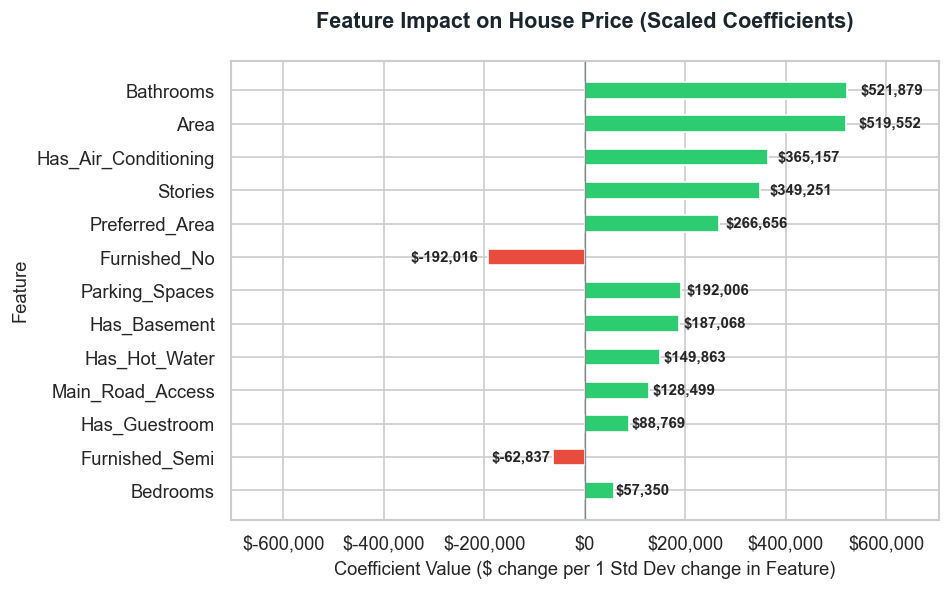

In [13]:
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_
}).sort_values(by='Coefficient', key=abs, ascending=True)

plt.figure(figsize=(8, 5))
colors = ['#E74C3C' if x < 0 else '#2ECC71' for x in importance_df['Coefficient']]
bars = plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors, height=0.5)

for bar in bars:
    width = bar.get_width()
    x_pos = width * 1.05 if width > 0 else width - (abs(width) * 0.1)
    ha_align = 'left' if width > 0 else 'right'
    plt.text(
        x_pos, 
        bar.get_y() + bar.get_height()/2,
        f"${width:,.0f}", 
        va='center', 
        ha=ha_align, 
        fontsize=9, 
        weight='bold'
    )

plt.axvline(x=0, color='#7F8C8D', linestyle='-', linewidth=0.8)
plt.title("Feature Impact on House Price (Scaled Coefficients)", weight='bold', color='#1A252C', pad=20)
plt.xlabel("Coefficient Value ($ change per 1 Std Dev change in Feature)")
plt.ylabel("Feature")
max_coeff = max(abs(importance_df['Coefficient']))
plt.xlim(-max_coeff * 1.35, max_coeff * 1.35)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x:,.0f}"))
plt.tight_layout()
plt.show()